ссылка: https://www.kaggle.com/datasets/shivamb/netflix-shows?resource=download

Датасет содержит информацию о фильмах и сериалах Netflix: название, режиссёр, актёры, страна, дата добавления, год выпуска, рейтинг, длительность, жанры и описание

In [100]:
# Импорт библиотек
import pandas as pd            # для работы с таблицами
import numpy as np             # для математических операций
import matplotlib.pyplot as plt # основа для графиков
import seaborn as sns           # красивые графики поверх matplotlib
import plotly.express as px     # интерактивные графики
import plotly.graph_objects as go # ещё один модуль для интерактивных графиков
from sklearn.feature_extraction import FeatureHasher  # для хэширования категорий

print("Библиотеки загружены")

Библиотеки загружены


In [101]:
# Загружаем файл
df = pd.read_csv('netflix_titles.csv')
print("Размер данных:", df.shape)
df.head()

Размер данных: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


A) Быстрый обзор данных

In [102]:
# Первые 5 строк
df.head()

# Последние 5 строк
df.tail()

# Размер
print("Строк:", df.shape[0], "Колонок:", df.shape[1])

# Информация о типах и пропусках
df.info()

# Статистика для числовых колонок
df.describe()

# Для категориальных и текстовых
df.describe(include=['object', 'str'])

Строк: 8807 Колонок: 12
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [103]:
# Пропуски
print(df.isnull().sum())

# Дубликаты
print("Дубликаты:", df.duplicated().sum())

# Типы данных: проверим, что release_year – число, date_added – дата
print(df.dtypes)

# Преобразуем date_added в datetime (осторожно: там могут быть пропуски)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Дубликаты: 0
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


B) Обработка пропусков

In [104]:
# Посмотрим процент пропусков
missing_percent = df.isnull().mean() * 100
print(missing_percent)

# Заполняем пропуски
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Удаляем строки с пропущенной датой
df = df.dropna(subset=['date_added'])

# Заполняем рейтинг модой
mode_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(mode_rating)

# Удаляем строки с пропущенной длительностью
df = df.dropna(subset=['duration'])

# Проверим, остались ли пропуски
print(df.isnull().sum())

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       1.112751
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


C) Расширенная статистика

In [105]:
# Числовые колонки: release_year, возможно, длительность (после обработки)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  min: {df[col].min()}")
    print(f"  max: {df[col].max()}")
    print(f"  mean: {df[col].mean():.2f}")
    print(f"  median: {df[col].median()}")
    # мода (первое значение)
    mode_val = df[col].mode()
    if not mode_val.empty:
        print(f"  mode: {mode_val[0]}")


release_year:
  min: 1925
  max: 2021
  mean: 2014.20
  median: 2017.0
  mode: 2018


In [106]:
df[['release_year']].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,release_year
0.05,1997.0
0.25,2013.0
0.50,2017.0
0.75,2019.0
0.95,2021.0


In [107]:
for col in numeric_cols:
    print(f"{col}: var={df[col].var():.2f}, skew={df[col].skew():.2f}, kurt={df[col].kurt():.2f}")
# Асимметрия release_year отрицательная (скорее всего, старых фильмов мало)

release_year: var=77.93, skew=-3.45, kurt=16.26


D) Feature Engineering

In [108]:
# Из date_added: год, месяц, день
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day

# Можно ещё извлечь сезон
df['season_added'] = df['month_added'] % 12 // 3 + 1  # 1: зима, 2: весна, 3: лето, 4: осень

In [109]:
# duration может быть "90 min" или "2 Seasons"
# Создадим две колонки: duration_min (для фильмов) и duration_seasons (для сериалов)
def extract_duration(row):
    if pd.isna(row['duration']):
        return pd.Series([None, None])
    dur_str = row['duration']
    if 'min' in dur_str:
        minutes = int(dur_str.replace(' min', ''))
        return pd.Series([minutes, 0])
    elif 'Season' in dur_str:
        seasons = int(dur_str.split()[0])
        return pd.Series([0, seasons])
    else:
        return pd.Series([None, None])

df[['duration_min', 'duration_seasons']] = df.apply(extract_duration, axis=1)

# Для фильмов duration_min > 0, для сериалов duration_seasons > 0

In [110]:
df['cast'] = df['cast'].fillna('Unknown')
df['cast'] = df['cast'].astype(str)
df['cast_count'] = df['cast'].apply(lambda x: len(x.split(',')) if x != 'Unknown' else 0)

In [111]:
# Выберем категориальные колонки: type, rating (и возможно country, но там много уникальных)
# Для type (Movie/TV Show)
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)

# Для rating тоже можно, но много значений (около 15)
# Лучше применить Label Encoding для порядка, либо оставить как есть

In [112]:
# Например, country (около 100+ уникальных) или listed_in (жанры)
# Используем FeatureHasher для listed_in
hasher = FeatureHasher(n_features=10, input_type='string')
# Преобразуем каждую строку жанров в список (разделитель запятая)
genre_lists = df['listed_in'].str.split(', ').tolist()
hashed_features = hasher.transform(genre_lists).toarray()
df_hashed = pd.DataFrame(hashed_features, columns=[f'genre_hash_{i}' for i in range(10)])
df = pd.concat([df, df_hashed], axis=1)

In [113]:
# Например, для страны: оставим топ-10, остальные "Other"
top_countries = df['country'].value_counts().nlargest(10).index
df['country_grouped'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')

E) Визуализация

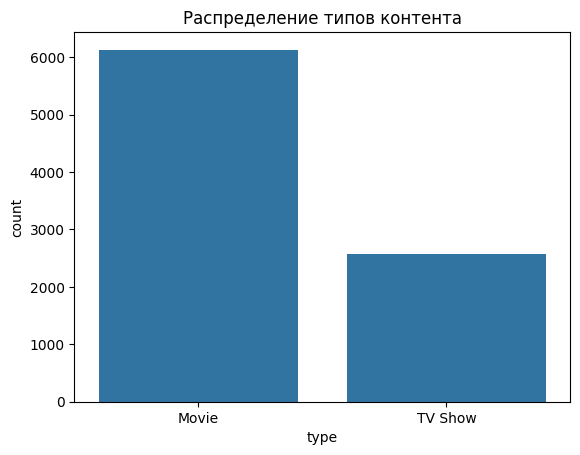

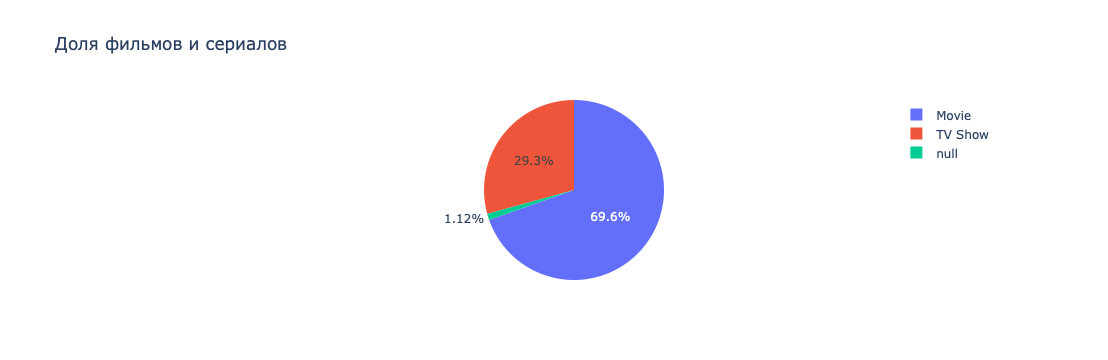

In [114]:
# Seaborn countplot
sns.countplot(data=df, x='type')
plt.title('Распределение типов контента')
plt.show()

# Plotly
fig = px.pie(df, names='type', title='Доля фильмов и сериалов')
fig.show()

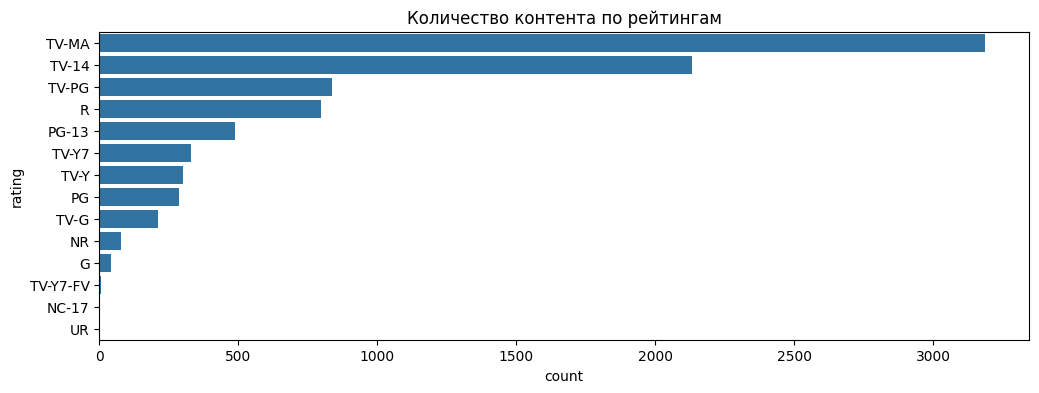

In [115]:
plt.figure(figsize=(12,4))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)
plt.title('Количество контента по рейтингам')
plt.show()

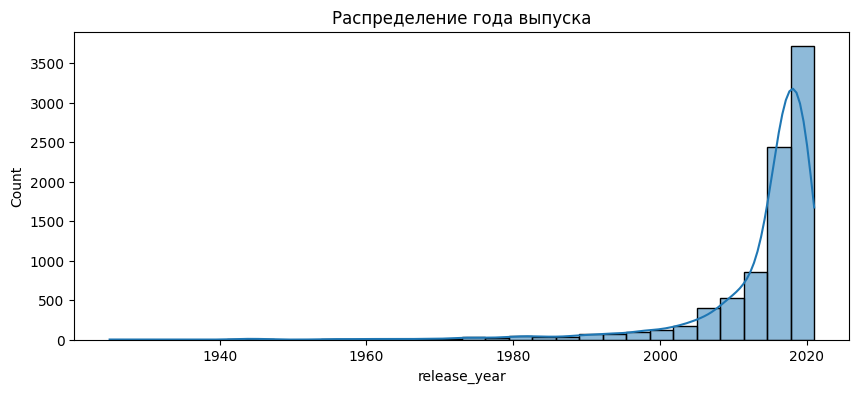

In [116]:
plt.figure(figsize=(10,4))
sns.histplot(df['release_year'], bins=30, kde=True)
plt.title('Распределение года выпуска')
plt.show()

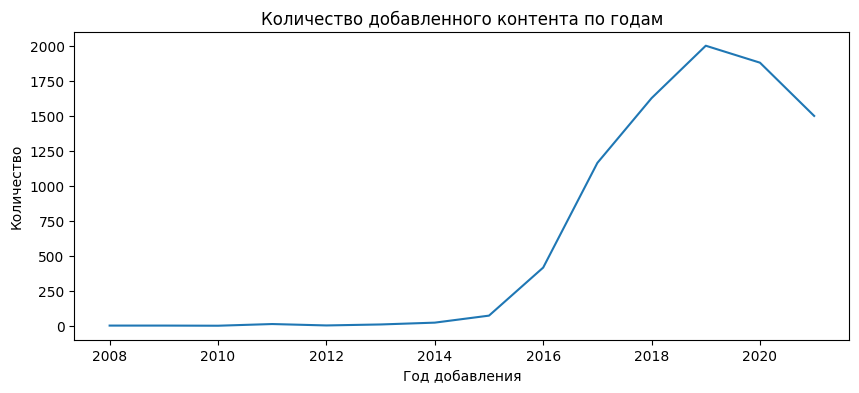

In [117]:
yearly = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,4))
sns.lineplot(x=yearly.index, y=yearly.values)
plt.title('Количество добавленного контента по годам')
plt.xlabel('Год добавления')
plt.ylabel('Количество')
plt.show()

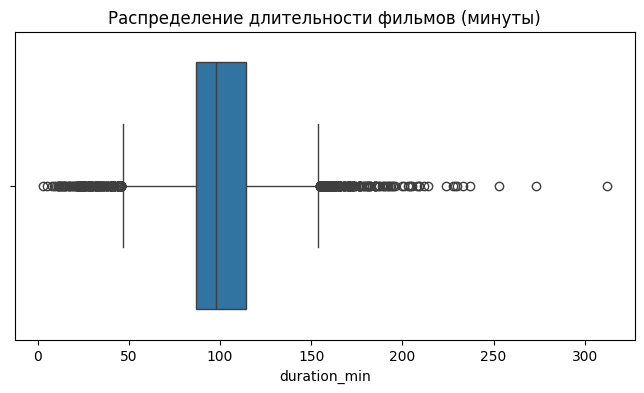

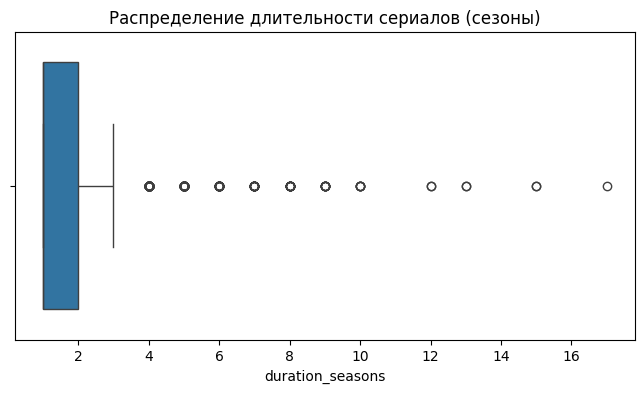

In [118]:
# Фильмы
plt.figure(figsize=(8,4))
sns.boxplot(x=df[df['type']=='Movie']['duration_min'])
plt.title('Распределение длительности фильмов (минуты)')
plt.show()

# Сериалы
plt.figure(figsize=(8,4))
sns.boxplot(x=df[df['type']=='TV Show']['duration_seasons'])
plt.title('Распределение длительности сериалов (сезоны)')
plt.show()

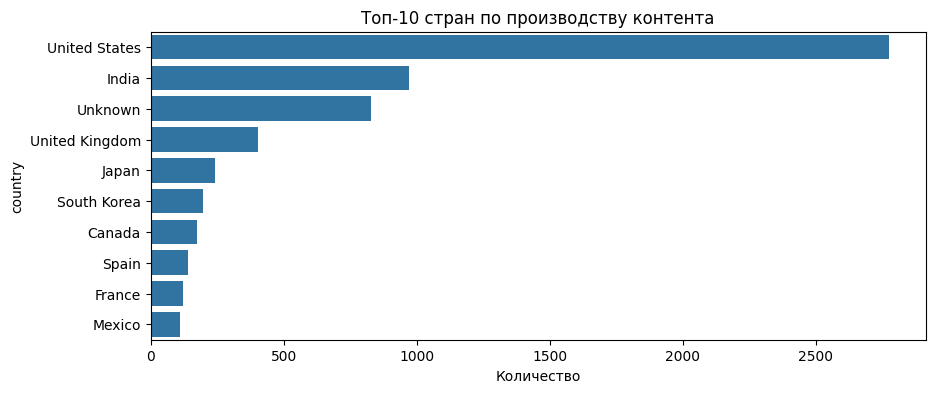

In [119]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Топ-10 стран по производству контента')
plt.xlabel('Количество')
plt.show()

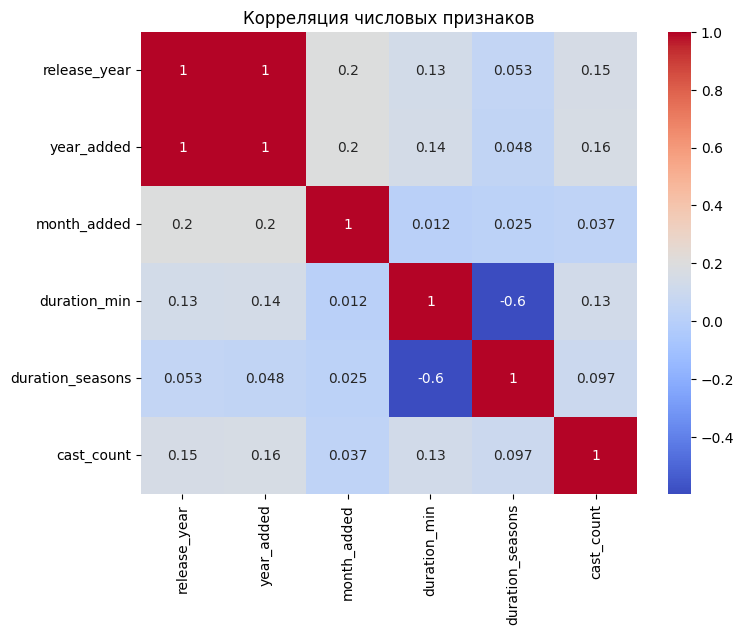

In [120]:
numeric_df = df[['release_year', 'year_added', 'month_added', 'duration_min', 'duration_seasons', 'cast_count']].copy()
# Заполним пропуски нулями для корреляции
numeric_df.fillna(0, inplace=True)

corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляция числовых признаков')
plt.show()
# Вывод: например, release_year и year_added сильно коррелируют? (обычно да)

### Что я понял про датасет Netflix:
1. Всего записей: ~8800, 12 колонок.
2. Основные пропуски были в `director`, `cast`, `country` – я заполнил их "Unknown".
3. `date_added` привёл к datetime и извлёк год, месяц, день.
4. Фильмов (~70%) больше, чем сериалов (~30%).
5. Самый частый рейтинг – TV-MA (для взрослых), затем TV-14.
6. Больше всего контента добавлено в 2019-2020 годах.
7. Основные страны-производители: США, Индия, Великобритания.
8. Длительность фильмов в основном 90-120 минут (есть выбросы до 300+ минут).
9. Сериалы чаще всего имеют 1 сезон, редко больше 3.
10. Количество актёров в cast варьируется от 0 (Unknown) до 20+.

### Гипотезы:
1. Сериалы стали добавлять чаще после 2015 года.
2. В разных странах преобладают разные рейтинги (например, в Индии больше семейного контента).
3. Контент с высоким рейтингом (TV-MA) чаще имеет более поздний год выпуска.

### Что делать дальше:
- Построить модель для предсказания типа контента (фильм/сериал) по описанию и другим признакам.
- Кластеризовать контент по жанрам и странам.
- Проанализировать тексты описаний (word cloud, тематическое моделирование).


- Я спросил у AI, как лучше обработать смешанную колонку duration (минуты/сезоны), и реализовал функцию извлечения.
- AI подсказал синтаксис FeatureHasher для жанров.
- Сам проверил распределения и скорректировал пороги для редких стран.